<p>
  <img src="https://upload.wikimedia.org/wikipedia/commons/f/fb/Escudo-UdeA.svg"
       alt="UdeA logo"
       height="190px"
       align="left"
       hspace="15px">
</p>

<h1 style="margin-top: 20px;"><b>Homework 1: Geiger Counter - statistical analysis</b></h1>

<hr>

<div align="right" style="font-size: 14px; line-height: 1.4;">
  <b>Estiven Castrillon Alzate</b><br>
  Institute of Physics<br>
  <i>Universidad de Antioquia</i><br>
  <span style="font-size: 12px;">Date: October 7, 2024</span>
</div>

<br><br>

Activity 1 (Recorded in the logbook)

Using the concepts learned in class and using the attached article "CountingCarsArticle" as a reference, develop the following:

Data collection

During class hours, access the page: https://luramire.github.io/GeigerCounter.io and collect radiation data using the remote setup for 30 minutes. This sends samples every 10 s.

Remember that the page must remain **open at all times** during data collection, otherwise the data count will reset.

The values n displayed on the page refer to the total counts up to that moment. To know how many arrived in interval i, it is necessary to make the difference between n_{i+1} - n_i.

Analysis

By performing a preliminary analysis of the data, determine if you find outliers. To do this, create a ``boxplot`` and remove those that do not meet the quartile criterion.

Obtain the mean value λ and the standard deviation of the data. Then, using that λ, create a simulated dataset that follows a Poisson distribution (help: it is recommended to use ``scipy.stats.poisson.rvs``).

Plot the real data and simulated data together. What differences or similarities do you find between the experimental and simulated data?

Create a residuals plot for both datasets and graph them together. Can you say that the data are distributed randomly?

Plot the histograms of each dataset and superimpose the theoretical distribution. Analyze and conclude about the results obtained.

Calculate the probability for experimental and simulated data that between 2 to 5 particles are detected in 10 s. How many events would you expect to see in 3 minutes?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import factorial
from scipy.stats import poisson

In [2]:
geiger_data = pd.read_csv('datos-geiger-19-02-2025 - Datos extraidos.csv')
geiger_data

,particulas
0,4
1,1
2,4
3,7
4,3
...,...
139,2
140,5
141,6
142,7


In [3]:
# Parameters of the data
N = 144
lam = np.mean(geiger_data)  # Mean
sig = np.std(geiger_data)  # Standard deviation

/home/estiven/Proyectos/physics-lab-experiments/.env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [4]:
mean, var, skew, kurt = poisson.stats(lam, moments='mvsk')
print(f"mean = {mean}, variance = {var}, standard deviation = {skew}, kurtosis = {kurt}")

mean = 3.2916666666666665, variance = 3.2916666666666665, standard deviation = 0.5511782546095504, kurtosis = 0.3037974683544304


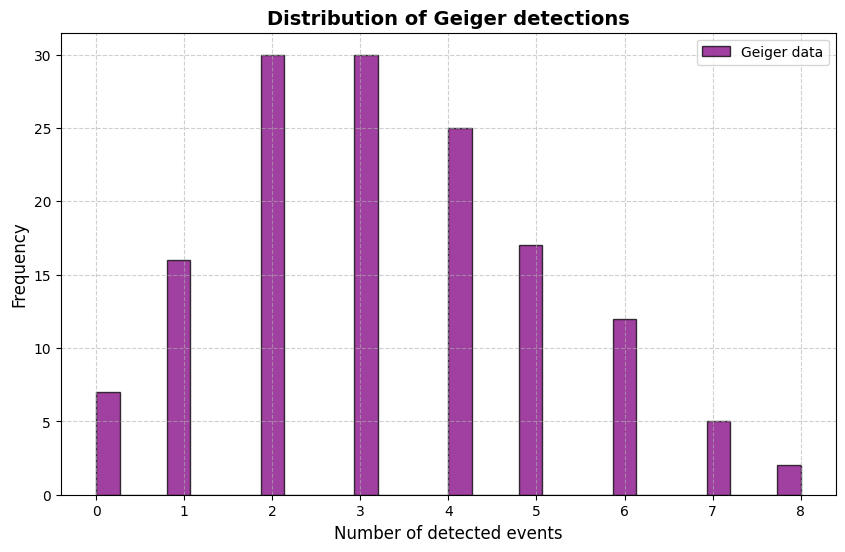

In [5]:
# Data collected experimentally
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(geiger_data, bins=30, color='purple', alpha=0.75, edgecolor='black', label="Geiger data")
ax.set_title("Distribution of Geiger detections", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of detected events", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
plt.show()

1. By performing a preliminary analysis of the data, determine if you find outliers. To do this, create a ``boxplot`` and remove those that do not meet the quartile criterion.

/tmp/ipykernel_13376/268078413.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


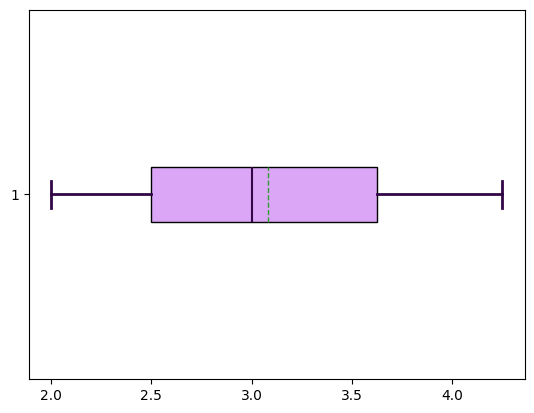

In [6]:
# Quartiles
quartiles = np.quantile(geiger_data, [0.25, 0.5, 0.75])
# Boxplot diagram (box and whiskers - point 1)
fig, ax = plt.subplots()
ax.boxplot(quartiles, vert=False, showmeans=True, meanline=True,
           medianprops=dict(color="#320647", linewidth=1.5),  # Color and thickness of median line
           flierprops=dict(marker="s", markerfacecolor="purple"),  # Mark outliers
           patch_artist=True,
           boxprops=dict(facecolor="#dca6f7"),  # Box background
           whiskerprops=dict(color="#320647", linewidth=2), capprops=dict(color="#320647", linewidth=2))  # Color of whiskers and whisker caps

fig.show()

2. Obtain the mean value λ and the standard deviation of the data. Then, using that λ, create a simulated dataset that follows a Poisson distribution (help: it is recommended to use ``scipy.stats.poisson.rvs``).

In [7]:
mean_lam = float((geiger_data.sum() / geiger_data.count()).iloc[0])  # Mean value of lambda
std_dev = np.sqrt(mean_lam)
print(f'The mean value λ is {mean_lam} and the standard deviation is {std_dev}')

# Simulated dataset
simulated_data = np.random.poisson(mean_lam, 144)  # Same amount of data as we have

The mean value λ is 3.2916666666666665 and the standard deviation is 1.8142950880897701


In [8]:
mean, var, skew, kurt = poisson.stats(mean_lam, moments='mvsk')
print(f"mean = {mean}, variance = {var}, standard deviation = {skew}, kurtosis = {kurt}")

mean = 3.2916666666666665, variance = 3.2916666666666665, standard deviation = 0.5511782546095504, kurtosis = 0.3037974683544304


3. Plot the real data and simulated data together. What differences or similarities do you find between the experimental and simulated data?

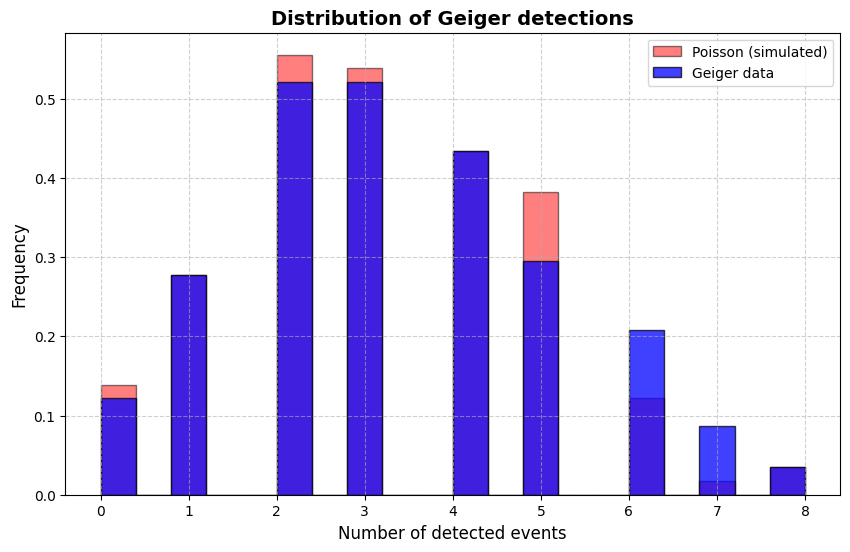

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram with labels and improvements
ax.hist(simulated_data, bins=20, color='red', alpha=0.5, edgecolor='black', label="Poisson (simulated)", density=True)
ax.hist(geiger_data, bins=20, color='blue', alpha=0.75, edgecolor='black', label="Geiger data", density=True)

ax.set_title("Distribution of Geiger detections", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of detected events", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

# Display the plot
plt.show()

The simulated data have a standard deviation greater than that of the data collected experimentally in class.

4. Create a residuals plot for both datasets and graph them together. Can you say that the data are distributed randomly?

In [10]:
df_simulated_data = pd.DataFrame({'Value': pd.Series(simulated_data).value_counts().index,
                                   'Frequency': pd.Series(simulated_data).value_counts().values})
df_simulated_data

,Value,Frequency
0,2,32
1,3,31
2,4,25
3,5,22
4,1,16
5,0,8
6,6,7
7,8,2
8,7,1


In [11]:
geiger_data1 = pd.DataFrame({'Value': pd.Series(geiger_data["particulas"]).value_counts().index,
                             'Frequency': pd.Series(geiger_data["particulas"]).value_counts().values})
geiger_data1

,Value,Frequency
0,3,30
1,2,30
2,4,25
3,5,17
4,1,16
5,6,12
6,0,7
7,7,5
8,8,2


In [12]:
residuals = []
value_r = []
for i in range(0, len(geiger_data1)):
    for k in range(0, len(df_simulated_data)):
        if geiger_data1["Value"][i] == df_simulated_data["Value"][k]:
            residuals.append(geiger_data1["Frequency"][i] - df_simulated_data["Frequency"][k])
            value_r.append(geiger_data1["Value"][i])

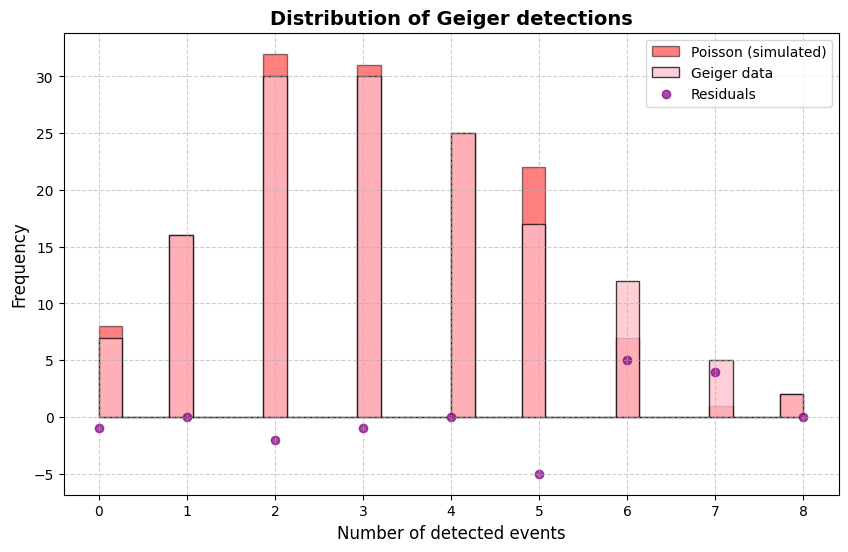

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(simulated_data, bins=30, color='red', alpha=0.5, edgecolor='black', label="Poisson (simulated)")
ax.hist(geiger_data, bins=30, color='pink', alpha=0.75, edgecolor='black', label="Geiger data")
ax.scatter(value_r, residuals, color="purple", alpha=0.7, label="Residuals")

ax.set_title("Distribution of Geiger detections", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of detected events", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
plt.show()

Since we observe that the residuals do not have a defined pattern, being randomly dispersed, we can say that indeed the data are distributed randomly.

5. Plot the histograms of each dataset and superimpose the theoretical distribution. Analyze and conclude about the results obtained.

In [14]:
def poisson(mean, x):
    y = ((mean ** x) * np.exp(-mean)) / factorial(x)
    return y

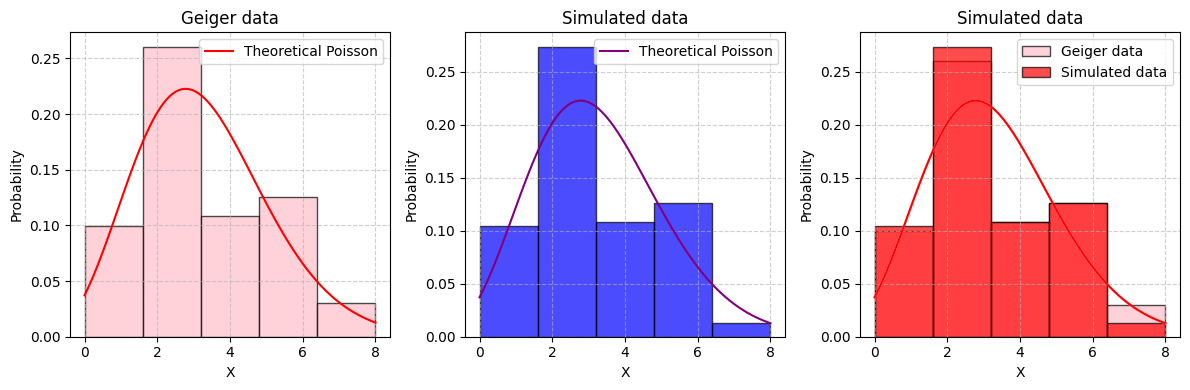

In [15]:
t = np.linspace(0, 8, 100)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# 1 Histogram of Geiger data
axes[0].hist(geiger_data, bins=5, color="pink", edgecolor="black", alpha=0.7, density=True)
axes[0].plot(t, poisson(lam, t), color="red", label="Theoretical Poisson")
axes[0].set_title("Geiger data")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Probability")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

# 2 Histogram of simulated data
axes[1].hist(simulated_data, bins=5, color="blue", edgecolor="black", alpha=0.7, density=True)
axes[1].plot(t, poisson(float(mean_lam), t), color="purple", label="Theoretical Poisson")
axes[1].set_title("Simulated data")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Probability")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

# 3 Superposition of both
axes[2].hist(geiger_data, bins=5, color="pink", edgecolor="black", alpha=0.7, density=True, label="Geiger data")
axes[2].plot(t, poisson(lam, t), color="pink")
axes[2].hist(simulated_data, bins=5, color="red", edgecolor="black", alpha=0.7, density=True, label="Simulated data")
axes[2].plot(t, poisson(float(mean_lam), t), color="red")
axes[2].set_title("Simulated data")
axes[2].set_xlabel("X")
axes[2].set_ylabel("Probability")
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

The theoretical distribution fits almost perfectly to the distribution of the data collected experimentally and to the distribution of the simulated data. The result implies that a good model of the physical problem was created.

6. Calculate the probability for experimental and simulated data that between 2 to 5 particles are detected in 10 s. How many events would you expect to see in 3 minutes?

In [16]:
# @title .
Pe, Ps = 0, 0  # Using the theoretical definition
for i in range(2, 6):
    Pe += poisson(lam, i)
    Ps += poisson(float(mean_lam), i)
print(f'The probability that between 2 to 5 particles are detected in 10s, with experimental data is {Pe}, \nThe probability that between 2 to 5 particles are detected in 10s, with simulated data is {Ps}')

The probability that between 2 to 5 particles are detected in 10s, with experimental data is 0.7242621893490389, 
The probability that between 2 to 5 particles are detected in 10s, with simulated data is 0.7242621893490389


In [17]:
# Using the data list
Pe, Ps = 0, 0  # Pe: Probability of experimental data, Ps: Probability of simulated data
for i in range(0, len(geiger_data1)):
    if geiger_data1["Value"][i] >= 2 and geiger_data1["Value"][i] <= 5:
        Pe += geiger_data1["Frequency"][i] / 144

for i in range(0, len(df_simulated_data)):
    if df_simulated_data["Value"][i] >= 2 and df_simulated_data["Value"][i] <= 5:
        Ps += df_simulated_data["Frequency"][i] / 144

print(f'The probability that between 2 to 5 particles are detected in 10s, with experimental data is {Pe}, \nThe probability that between 2 to 5 particles are detected in 10s, with simulated data is {Ps}')

The probability that between 2 to 5 particles are detected in 10s, with experimental data is 0.7083333333333334, 
The probability that between 2 to 5 particles are detected in 10s, with simulated data is 0.763888888888889


In [18]:
# In a 3-minute period, lambda is modified
lam_3min = lam * 180 / 10
mean_lam_3min = float(mean_lam) * 180 / 10
print(f'In 3 minutes, {lam_3min} events are expected with experimental data and {mean_lam_3min} events are expected with simulated data')

In 3 minutes, 59.25 events are expected with experimental data and 59.25 events are expected with simulated data
